# N1 · activation patching: 因果定位

> 配套 12.3-L2 · mech interp 最核心工具。clean/corrupt 对照 (玩具: 只差最后一个 token →答案不同)。
> 把 clean 激活逐个 (层,位置) patch 进 corrupt 运行, 看哪里能**恢复** clean 行为 = 那里因果携带答案信息。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import patching as pt
import tiny_transformer as tt
import numpy as np, torch
torch.manual_seed(0)
Xi,Yi=tt.make_data(2000,seed=0)
model=tt.build_model(); tt.train(model,Xi,Yi,epochs=800)
print('玩具 transformer 就绪 (increment-mod-V)')

玩具 transformer 就绪 (increment-mod-V)


## 1. clean / corrupt 对照 (只差最后一个 token)

In [2]:
clean, corrupt, ca, cora = pt.make_clean_corrupt(seed=3)
print(f'clean   {clean[0]} → 答案 {ca}')
print(f'corrupt {corrupt[0]} → 答案 {cora}  (只改了最后一个 token)')
print('问题: 哪个位置/层 因果携带了"答案"信息?')

clean   [ 9 10 11  0  1  2  3  4] → 答案 5
corrupt [ 9 10 11  0  1  2  3  5] → 答案 6  (只改了最后一个 token)
问题: 哪个位置/层 因果携带了"答案"信息?


## 2. activation patching 恢复率热图

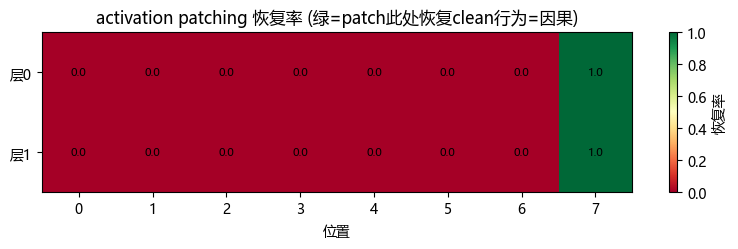

→ 只有「最后位置」patch 能恢复 (恢复率≈1), 其它≈0 → 答案信息因果地在最后位置。
  (increment 任务里 next=last+1, 所以只有最后 token 决定答案 — patching 干净地证明了这点)


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
grid, info = pt.patch_recovery(model, seed=3)
fig, ax = plt.subplots(figsize=(8,2.6))
im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_yticks(range(tt.N_LAYERS)); ax.set_yticklabels([f'层{L}' for L in range(tt.N_LAYERS)])
ax.set_xticks(range(tt.SEQ)); ax.set_xlabel('位置'); ax.set_title('activation patching 恢复率 (绿=patch此处恢复clean行为=因果)')
for L in range(tt.N_LAYERS):
    for p in range(tt.SEQ):
        ax.text(p, L, f'{grid[L,p]:.1f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='恢复率'); plt.tight_layout(); plt.show()
best = np.unravel_index(np.argmax(grid), grid.shape)
print(f'→ 只有「最后位置」patch 能恢复 (恢复率≈1), 其它≈0 → 答案信息因果地在最后位置。')
print(f'  (increment 任务里 next=last+1, 所以只有最后 token 决定答案 — patching 干净地证明了这点)')

## 3. 这就是「因果」而非「相关」
- 探针 (M12.2) 能从很多位置读出信息 (相关), 但 patching 证明**只有最后位置因果负责**。
- 这是 mech interp 的命门: **动手改 (patch), 看行为变化 (因果)**, 不是看激活猜 (相关)。

## 4. 反思
你用 activation patching 做了**因果定位**。带走:
- **patching**: clean 激活贴进 corrupt, 看恢复; 恢复=该处因果携带行为信息 (充分性)。
- **clean/corrupt 对照是灵魂**: 只差你关心的信息, 定位才干净 (接 M9.4)。
- 热图 = 因果信息流地图; 玩具里答案信息干净地定位在最后位置。
> 真 gpt2 上同理: patching "capital of France" 能定位国家名信息在哪层/位置被搬到答案 (causal tracing)。
下一步 N2: ablation 找「必要」组件 (和 patching 的充分互补 = 充要)。